In [24]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [25]:
# Carregar os dados
df_vendas = pd.read_csv('/content/vendas.csv')

In [26]:
# Mostrar as 5 primeiras linhas do dataset.
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste


In [27]:
# Exibir o número total de registros (linhas).
print("Total de registros:", df_vendas.shape[0])

Total de registros: 100


In [28]:
# Calcular a receita total (coluna quantidade multiplicada pela coluna preco_unitario).
df_vendas['receita'] = df_vendas['quantidade'] * df_vendas['preco_unitario']
receita_total = df_vendas['receita'].sum()
print("Receita total:", receita_total)

Receita total: 845852


In [29]:
# Conectar com SQL
conn = sqlite3.connect(":memory:")
df_vendas.to_sql("vendas", conn, index=False, if_exists="replace")

100

In [30]:
# Filtrar e exibir as vendas da categoria "Eletrônicos".
filtra_produto_eletronicos = pd.read_sql_query("SELECT * FROM vendas WHERE categoria = 'Eletrônicos'", conn)
filtra_produto_eletronicos

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita
0,2025-07-24,Tablet D,Eletrônicos,2,4893,Fernanda,Sudeste,9786
1,2025-05-20,Monitor B,Eletrônicos,1,3060,Lucas,Sul,3060
2,2025-06-01,Celular A,Eletrônicos,3,516,João,Centro-Oeste,1548
3,2025-04-22,Celular A,Eletrônicos,2,1018,Fernanda,Nordeste,2036
4,2025-11-24,Notebook X,Eletrônicos,1,2670,Ana,Sul,2670
5,2025-05-30,Tablet D,Eletrônicos,4,2575,Maria,Nordeste,10300
6,2025-09-19,Notebook X,Eletrônicos,2,2778,Rafael,Norte,5556
7,2025-01-30,Notebook X,Eletrônicos,5,1006,Lucas,Sudeste,5030
8,2025-07-07,Tablet D,Eletrônicos,2,2533,Camila,Sul,5066
9,2025-11-20,Notebook X,Eletrônicos,4,3998,Pedro,Nordeste,15992


In [31]:
# Identificar e exibir o produto mais vendido (em quantidade).
produto_mais_vendido = pd.read_sql_query("""
SELECT produto, categoria, SUM(quantidade) AS total_vendido
FROM vendas
GROUP BY produto
ORDER BY total_vendido
DESC LIMIT 1""", conn)
produto_mais_vendido

,produto,categoria,total_vendido
0,Sofá Q,Móveis,30


In [32]:
# Descobrir e exibir a região com maior valor de compras.
regiao_maior_receita = pd.read_sql_query("""
SELECT regiao, SUM(receita) AS total_receita
FROM vendas
GROUP BY regiao
ORDER BY total_receita DESC
LIMIT 1
""", conn)
regiao_maior_receita

,regiao,total_receita
0,Sudeste,245605


## Desafio extra

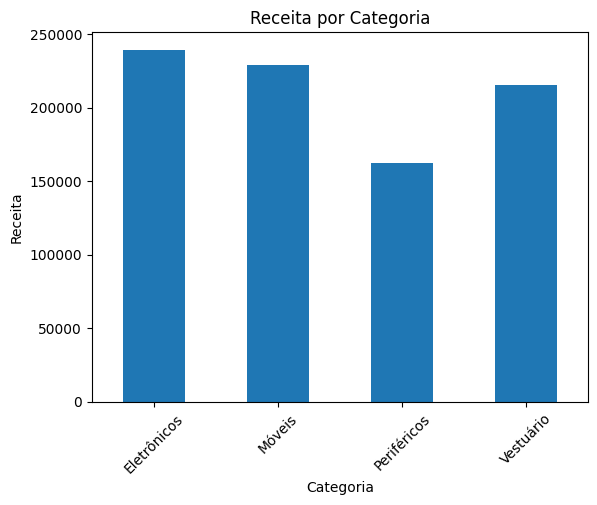

In [34]:
# Gráfico de barras mostrando a receita por categoria.
receita_categoria = df_vendas.groupby("categoria")["receita"].sum()

receita_categoria.plot(kind="bar")
plt.title("Receita por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Receita")
plt.xticks(rotation=45)
plt.show()

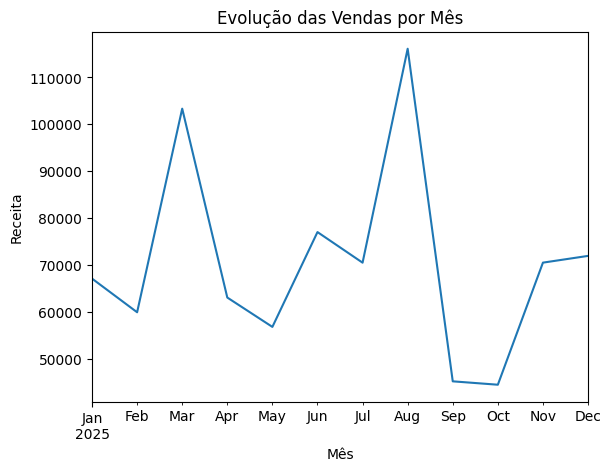

In [36]:
# Gráfico de linha mostrando a evolução das vendas por mês.
df_vendas["data"] = pd.to_datetime(df_vendas["data"])

vendas_mes = df_vendas.groupby(
    df_vendas["data"].dt.to_period("M")
)["receita"].sum()

vendas_mes.plot(kind="line")
plt.title("Evolução das Vendas por Mês")
plt.xlabel("Mês")
plt.ylabel("Receita")
plt.show()

In [39]:
# Montar uma tabela dinâmica com receita por região × categoria.
tabela_dinamica = pd.pivot_table(
    df_vendas,
    values="receita",
    index="regiao",
    columns="categoria",
    aggfunc="sum"
)

tabela_dinamica

categoria,Eletrônicos,Móveis,Periféricos,Vestuário
regiao,,,,
Centro-Oeste,39546,44884,25192,24106
Nordeste,51890,22870,24383,52659
Norte,38116,67464,11935,31561
Sudeste,51158,62888,69055,62504
Sul,58679,30683,31720,44559


In [40]:
# Criar um relatório exportado em .xlsx ou .pdf.
tabela_dinamica.to_excel("relatorio_vendas.xlsx")